In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = '/content/drive/MyDrive/pbmc3k-scrna-shap'
DATA_DIR = f'{PROJECT_DIR}/data'
RESULTS_DIR = f'{PROJECT_DIR}/results'
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
print('Uninstalling conflicting packages...')
!pip uninstall numpy scipy pandas scanpy anndata shap celltypist -y -q
print('Uninstallation complete. Now installing compatible versions...')


Uninstalling conflicting packages...
Uninstallation complete. Now installing compatible versions...


In [3]:
# Perform a clean uninstall of all potentially conflicting packages
print('Uninstalling conflicting packages...')
!pip uninstall numpy scipy pandas scanpy anndata shap celltypist -y -q
print('Uninstallation complete. Now installing compatible versions...')

# Install specific compatible versions of numpy, scipy, and pandas first
# These versions (numpy==1.26.4, scipy==1.11.4, pandas==2.2.2) are known to be compatible with Python 3.12, scanpy, and Google Colab
!pip install numpy==1.26.4 scipy==1.11.4 pandas==2.2.2 -q

# Then install scanpy and its ecosystem packages
!pip install scanpy anndata leidenalg python-igraph shap celltypist -q

print('\nInstallation of compatible packages complete.')
print('Please RESTART RUNTIME (Runtime > Restart runtime) and then RUN ALL CELLS (Runtime > Run all) for changes to take effect.')

Uninstalling conflicting packages...
Uninstallation complete. Now installing compatible versions...
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
zarr 3.3.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
fast-array-utils 1.5 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires scipy>=1.13, but you have scipy 1.11.4 which is incompatible.
libpysal 4.14.1 requires scipy>=1.12.0, but you have scipy 1.11.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires scipy>=1.13, but you have scipy 1.11.4 which is incompatible.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
spopt 0.7.0 requires scip

In [4]:
import scanpy as sc
import anndata
import shap
import celltypist

print("Scanpy:", sc.__version__)
print("AnnData:", anndata.__version__)
print("SHAP:", shap.__version__)
print("CellTypist:", celltypist.__version__)

Scanpy: 1.12.3
AnnData: 0.13.2
SHAP: 0.52.0
CellTypist: 1.7.1


/usr/local/lib/python3.12/dist-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv


In [5]:
import scanpy as sc
import anndata as ad
import numpy as np
import matplotlib.pyplot as plt

sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=100, facecolor='white')

In [6]:
adata = sc.datasets.pbmc3k()
adata.var_names_make_unique()

print(adata)
print(f"\nCells: {adata.n_obs}, Genes: {adata.n_vars}")

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'
    layers: None (.X)

Cells: 2700, Genes: 32738


In [7]:
import os

PROJECT_DIR = '/content/drive/MyDrive/pbmc3k-scrna-shap'
DATA_DIR = f'{PROJECT_DIR}/data'
RESULTS_DIR = f'{PROJECT_DIR}/results'

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

In [8]:
adata.write(f"{DATA_DIR}/pbmc3k_raw.h5ad")

In [9]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

print(f"After basic filtering — Cells: {adata.n_obs}, Genes: {adata.n_vars}")

After basic filtering — Cells: 2700, Genes: 13714


In [10]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

adata.obs[['n_genes_by_counts', 'total_counts', 'pct_counts_mt']].describe()

,n_genes_by_counts,total_counts,pct_counts_mt
count,2700.000000,2700.000000,2700.000000
mean,845.546667,2365.376953,2.216642
std,281.347923,1093.379028,1.166707
min,212.000000,546.000000,0.000000
25%,690.000000,1755.750000,1.537264
50%,816.000000,2196.000000,2.030800
75%,952.000000,2762.250000,2.643177
max,3400.000000,15818.000000,22.569027


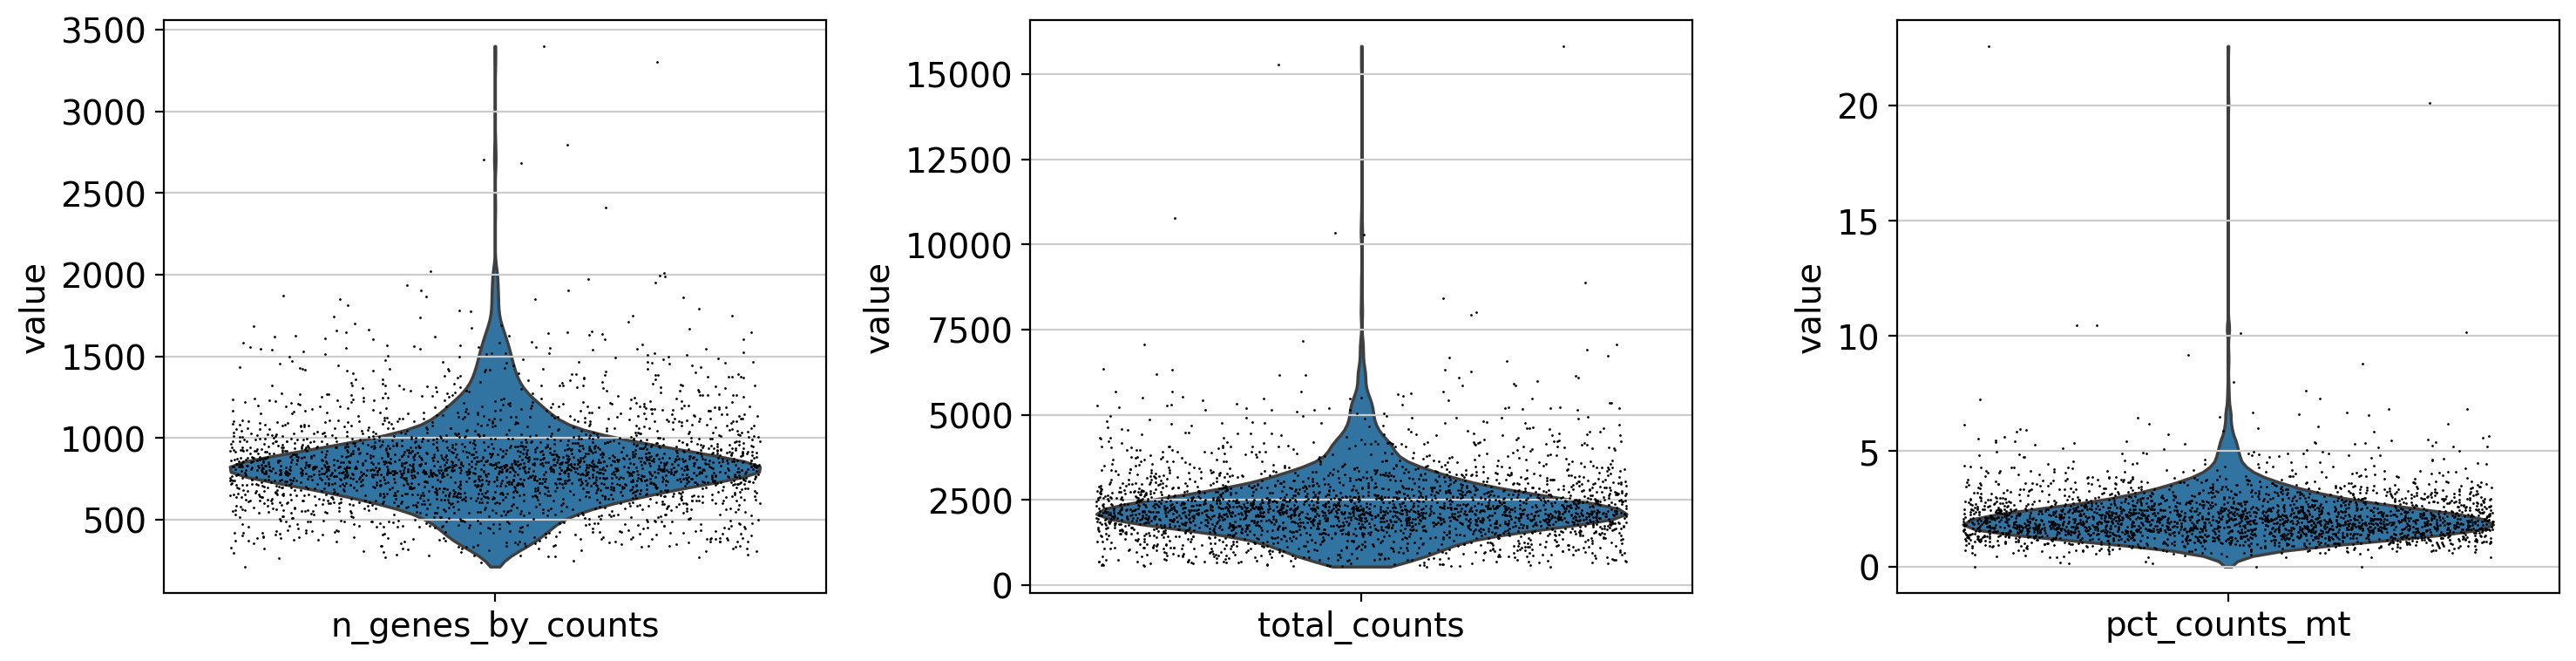

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sc.pl.violin(adata, ['n_genes_by_counts'], jitter=0.4, ax=axes[0], show=False)
sc.pl.violin(adata, ['total_counts'], jitter=0.4, ax=axes[1], show=False)
sc.pl.violin(adata, ['pct_counts_mt'], jitter=0.4, ax=axes[2], show=False)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/qc_violin_plots.png", dpi=150, bbox_inches='tight')
plt.show()

In [12]:
adata = sc.read_h5ad(f"{DATA_DIR}/pbmc3k_raw.h5ad")

print(adata)

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'
    layers: None (.X)


In [15]:
adata.var['mt'] = adata.var_names.str.startswith('MT-') # Annotate mitochondrial genes
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

# Display summary statistics of the newly calculated QC metrics
display(adata.obs[['n_genes_by_counts', 'total_counts', 'pct_counts_mt']].describe())

,n_genes_by_counts,total_counts,pct_counts_mt
count,2700.000000,2700.000000,2700.000000
mean,846.994074,2366.900391,2.215132
std,282.104964,1094.261963,1.165438
min,212.000000,548.000000,0.000000
25%,690.000000,1757.750000,1.536238
50%,817.000000,2197.000000,2.029639
75%,953.250000,2763.000000,2.640218
max,3422.000000,15844.000000,22.569027


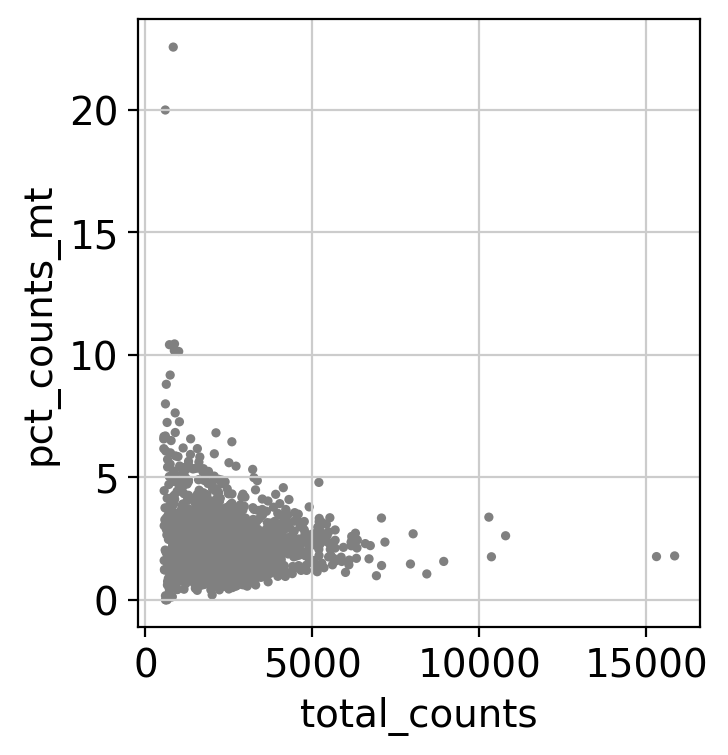

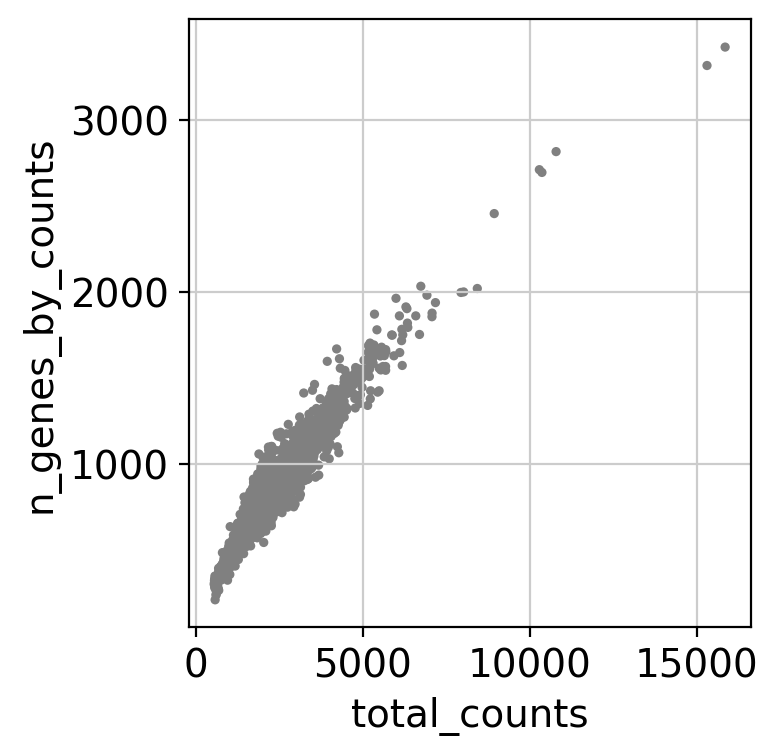

In [16]:
import scanpy as sc
import matplotlib.pyplot as plt

sc.pl.scatter(adata, x='total_counts', y='pct_counts_mt', show=False)
plt.savefig(f"{RESULTS_DIR}/qc_scatter_counts_vs_mito.png", dpi=150, bbox_inches='tight')
plt.show()

sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts', show=False)
plt.savefig(f"{RESULTS_DIR}/qc_scatter_counts_vs_genes.png", dpi=150, bbox_inches='tight')
plt.show()

In [17]:
import numpy as np
import scipy as sp

print(f"NumPy version: {np.__version__}")
print(f"SciPy version: {sp.__version__}")

NumPy version: 2.5.2
SciPy version: 1.18.0


In [18]:
adata = adata[adata.obs.n_genes_by_counts < 2500, :]
adata = adata[adata.obs.pct_counts_mt < 5, :]

print(f"After QC filtering — Cells: {adata.n_obs}, Genes: {adata.n_vars}")

After QC filtering — Cells: 2638, Genes: 32738


In [19]:
adata.layers['counts'] = adata.X.copy()

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

adata.layers['lognorm'] = adata.X.copy()

Highly variable genes: 2013 / 32738


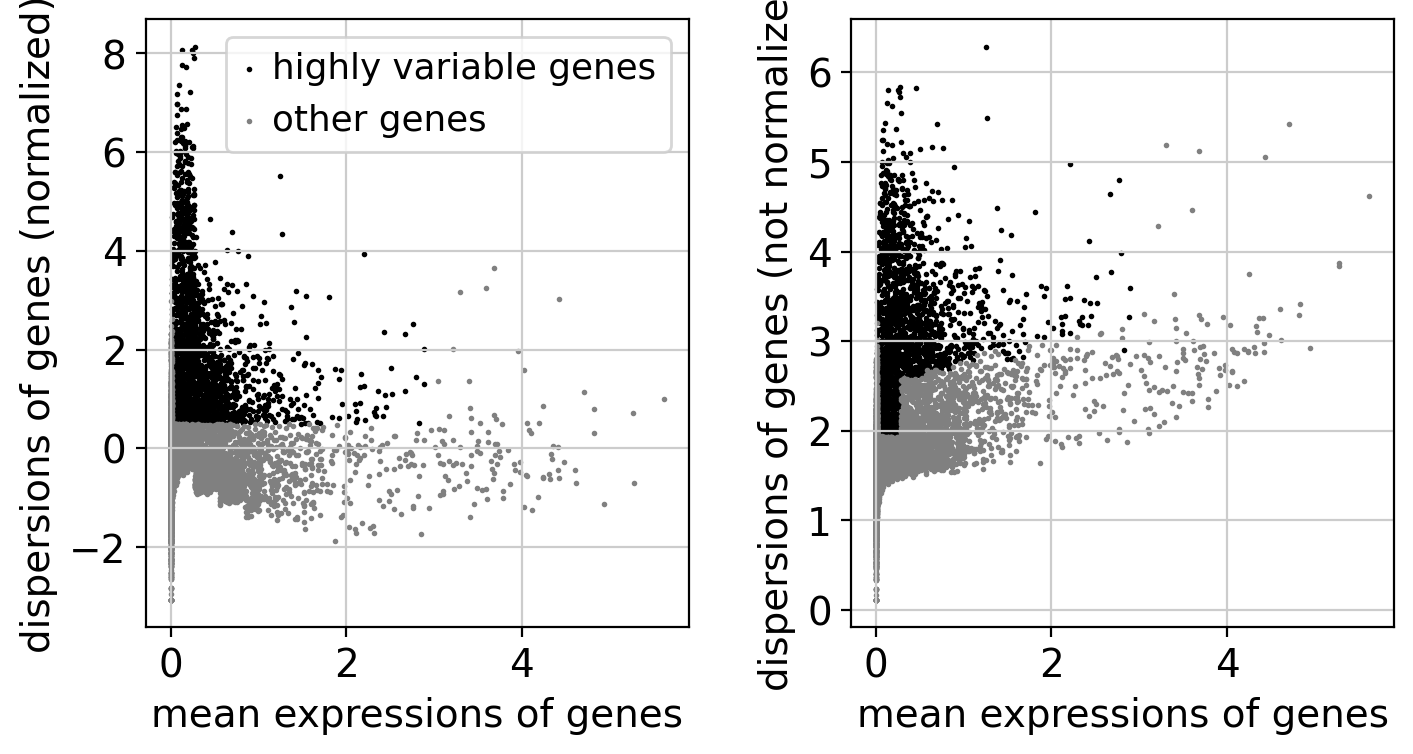

In [20]:
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)

print(f"Highly variable genes: {adata.var.highly_variable.sum()} / {adata.n_vars}")

sc.pl.highly_variable_genes(adata, show=False)
plt.savefig(f"{RESULTS_DIR}/highly_variable_genes.png", dpi=150, bbox_inches='tight')
plt.show()

In [21]:
adata.raw = adata

adata_hvg = adata[:, adata.var.highly_variable].copy()
print(f"Subsetted to HVGs — shape: {adata_hvg.shape}")

Subsetted to HVGs — shape: (2638, 2013)


In [22]:
adata_hvg.write(f"{DATA_DIR}/pbmc3k_processed.h5ad")
print("Saved processed AnnData to Drive")
print(f"\nSummary:")
print(f"  Final cells: {adata_hvg.n_obs}")
print(f"  HVG genes: {adata_hvg.n_vars}")
print(f"  Layers stored: {list(adata_hvg.layers.keys())}")
print(f"  Full gene set preserved in .raw: {adata_hvg.raw.shape if adata_hvg.raw is not None else 'None'}")

Saved processed AnnData to Drive

Summary:
  Final cells: 2638
  HVG genes: 2013
  Layers stored: [None, 'counts', 'lognorm']
  Full gene set preserved in .raw: (2638, 32738)


In [23]:
adata = sc.read_h5ad(f'{DATA_DIR}/pbmc3k_processed.h5ad')
print(adata)

AnnData object with n_obs × n_vars = 2638 × 2013
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p'
    layers: 'counts', 'lognorm', None (.X)


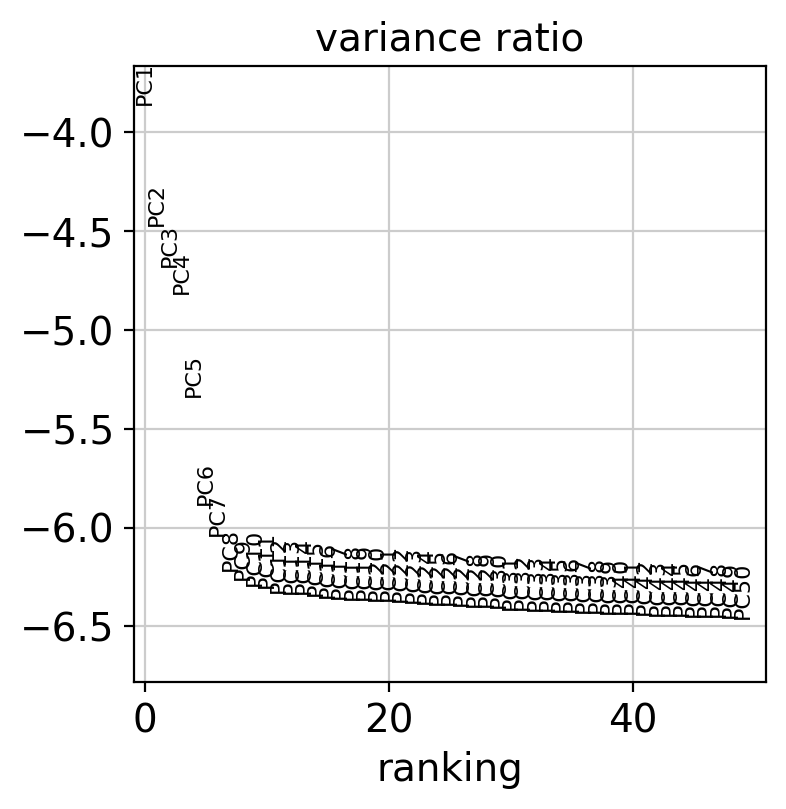

In [24]:
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver='arpack')

sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True, show=False)
plt.savefig(f'{RESULTS_DIR}/pca_variance_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
N_PCS = 15

In [26]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=N_PCS)
sc.tl.umap(adata)

Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7a2775b209a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/ctypes/__init__.py", line 379, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: dlopen() error


In [27]:
sc.tl.leiden(adata, resolution=0.5, key_added='leiden')

print(adata.obs['leiden'].value_counts())

leiden
0    1179
1     445
2     344
3     268
4     199
5     159
6      31
7      13
Name: count, dtype: int64


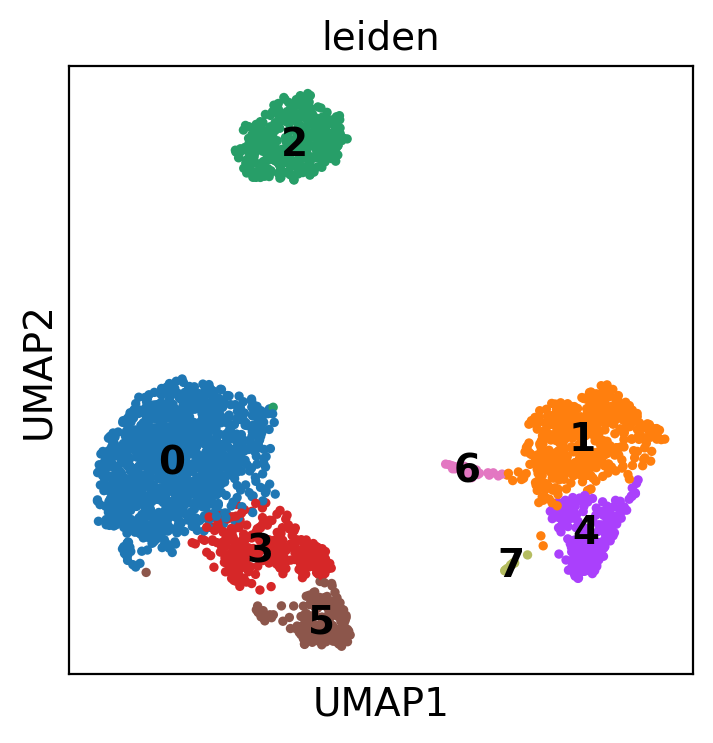

In [28]:
sc.pl.umap(adata, color=['leiden'], legend_loc='on data', show=False)
plt.savefig(f'{RESULTS_DIR}/umap_leiden_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

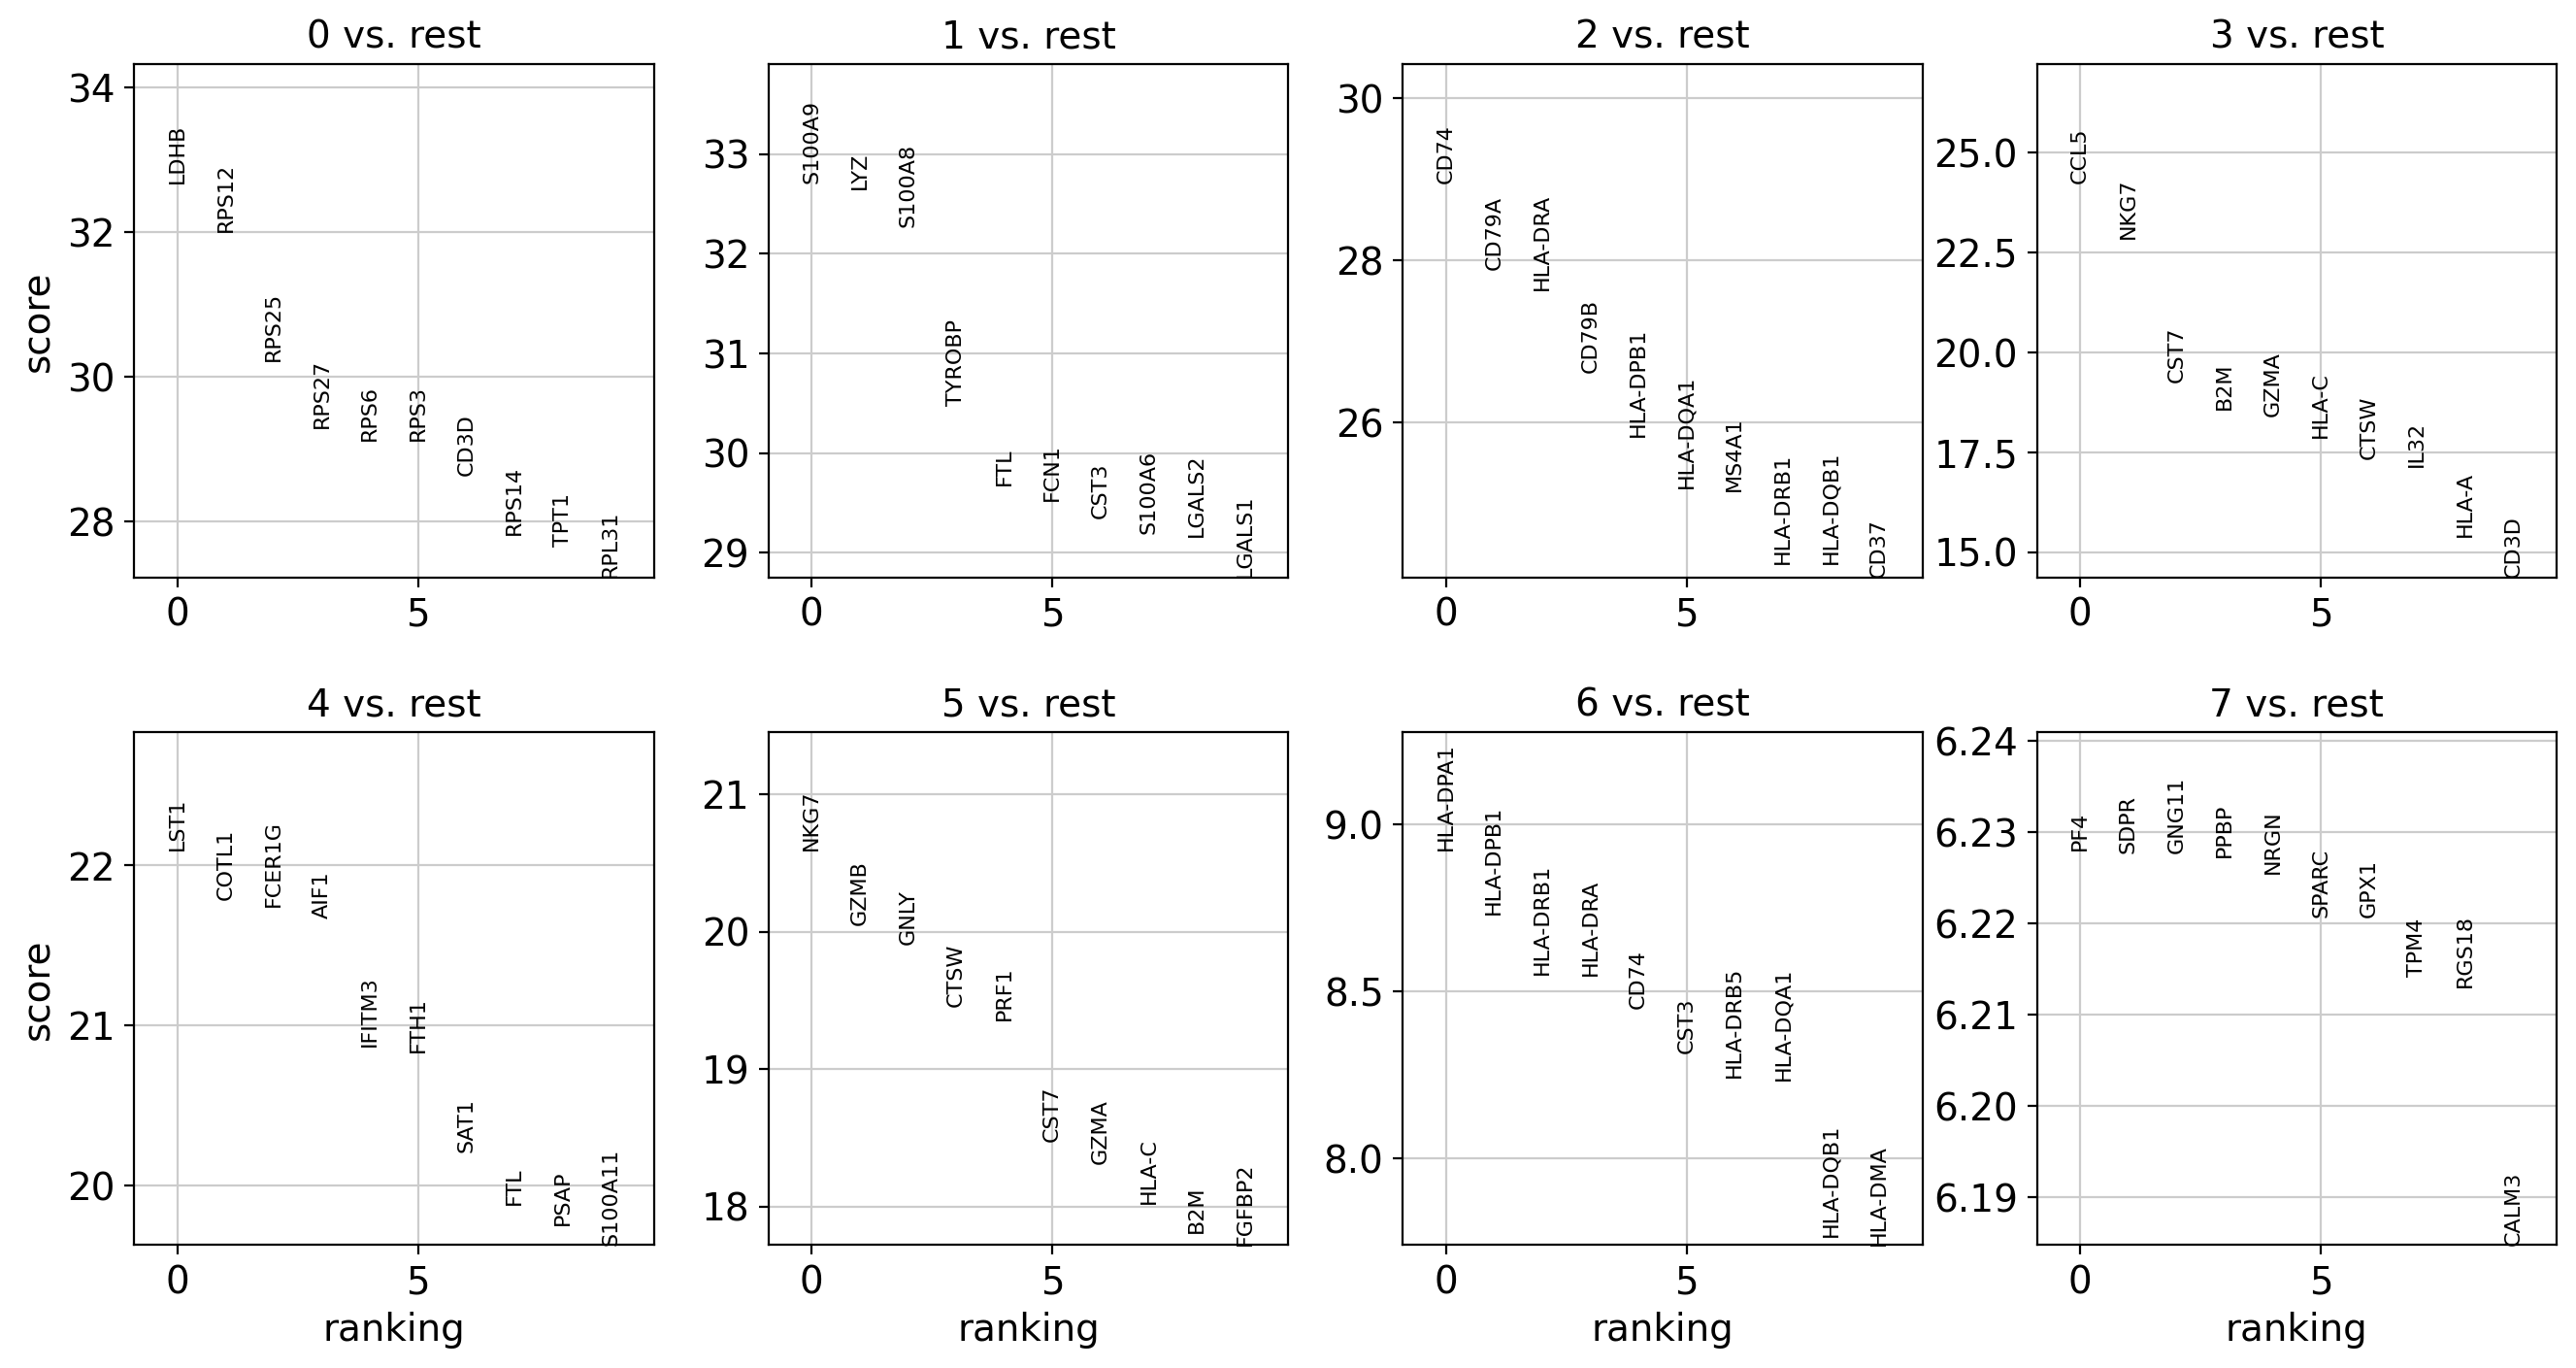

In [29]:
sc.tl.rank_genes_groups(adata, groupby='leiden', method='wilcoxon', use_raw=True)

sc.pl.rank_genes_groups(adata, n_genes=10, sharey=False, show=False)
plt.savefig(f'{RESULTS_DIR}/rank_genes_groups.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
import pandas as pd

result = adata.uns['rank_genes_groups']
groups = result['names'].dtype.names

top_markers = pd.DataFrame(
    {group: result['names'][group][:10] for group in groups}
)
top_markers.to_csv(f'{RESULTS_DIR}/top_marker_genes_per_cluster.csv', index=False)
top_markers

,0,1,2,3,4,5,6,7
0,LDHB,S100A9,CD74,CCL5,LST1,NKG7,HLA-DPA1,PF4
1,RPS12,LYZ,CD79A,NKG7,COTL1,GZMB,HLA-DPB1,SDPR
2,RPS25,S100A8,HLA-DRA,CST7,FCER1G,GNLY,HLA-DRB1,GNG11
3,RPS27,TYROBP,CD79B,B2M,AIF1,CTSW,HLA-DRA,PPBP
4,RPS6,FTL,HLA-DPB1,GZMA,IFITM3,PRF1,CD74,NRGN
5,RPS3,FCN1,HLA-DQA1,HLA-C,FTH1,CST7,CST3,SPARC
6,CD3D,CST3,MS4A1,CTSW,SAT1,GZMA,HLA-DRB5,GPX1
7,RPS14,S100A6,HLA-DRB1,IL32,FTL,HLA-C,HLA-DQA1,TPM4
8,TPT1,LGALS2,HLA-DQB1,HLA-A,PSAP,B2M,HLA-DQB1,RGS18
9,RPL31,LGALS1,CD37,CD3D,S100A11,FGFBP2,HLA-DMA,CALM3


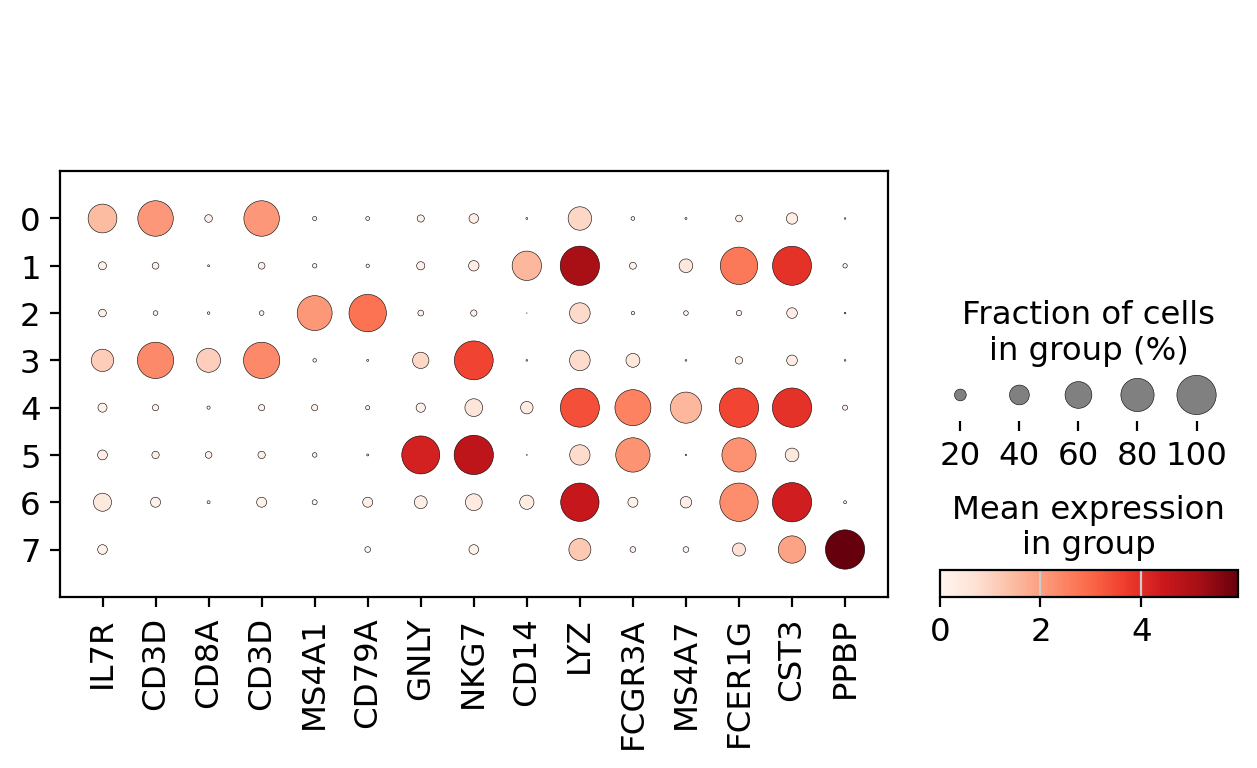

In [32]:
canonical_markers = {
    'CD4 T': ['IL7R', 'CD3D'],
    'CD8 T': ['CD8A', 'CD3D'],
    'B cell': ['MS4A1', 'CD79A'],
    'NK': ['GNLY', 'NKG7'],
    'CD14 Mono': ['CD14', 'LYZ'],
    'FCGR3A Mono': ['FCGR3A', 'MS4A7'],
    'DC': ['FCER1G', 'CST3'],
    'Megakaryocyte': ['PPBP'],
}
all_markers = [g for genes in canonical_markers.values() for g in genes]

sc.pl.dotplot(adata, all_markers, groupby='leiden', use_raw=True, show=False)
plt.savefig(f'{RESULTS_DIR}/dotplot_canonical_markers.png', dpi=150, bbox_inches='tight')
plt.show()

In [33]:
cluster_to_celltype = {
    '0': 'CD4 T',
    '1': 'CD14 Mono',
    '2': 'B cell',
    '3': 'CD8 T',
    '4': 'FCGR3A Mono',
    '5': 'NK',
    '6': 'DC',
    '7': 'Megakaryocyte',
}

adata.obs['cell_type'] = adata.obs['leiden'].map(cluster_to_celltype).astype('category')
print(adata.obs['cell_type'].value_counts())

cell_type
CD4 T            1179
CD14 Mono         445
B cell            344
CD8 T             268
FCGR3A Mono       199
NK                159
DC                 31
Megakaryocyte      13
Name: count, dtype: int64


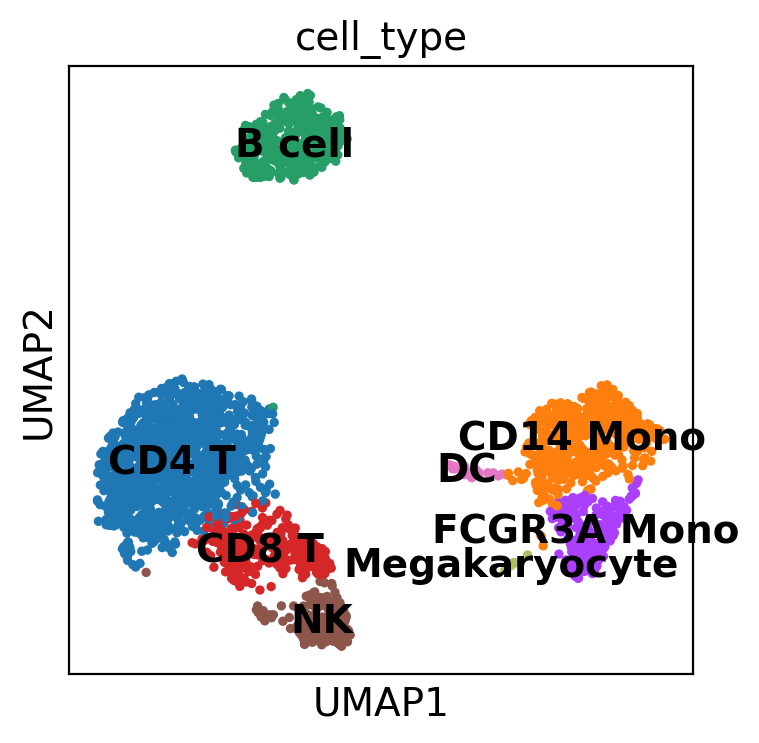

In [34]:
sc.pl.umap(adata, color=['cell_type'], legend_loc='on data', show=False)
plt.savefig(f'{RESULTS_DIR}/umap_cell_types.png', dpi=150, bbox_inches='tight')
plt.show()

In [35]:
adata.write(f'{DATA_DIR}/pbmc3k_annotated.h5ad')
print('Saved annotated AnnData to Drive')
print(f"Clusters: {adata.obs['leiden'].nunique()}")
print(f"Cell types assigned: {adata.obs['cell_type'].nunique()}")

Saved annotated AnnData to Drive
Clusters: 8
Cell types assigned: 8
